In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_metrics(df, metric_names):
    # Get unique sigma values
    unique_sigmas = df['sigma'].unique()
    
    # Create a 3x3 grid of subplots
    fig, axes = plt.subplots(3, 3, figsize=(15, 15))
    axes = axes.flatten()  # Flatten for easier indexing
    
    colors = ['b', 'r']
    linestyles = ['-', '--']
    
    # Create plots for each sigma value
    for idx, sigma in enumerate(unique_sigmas):
        if idx >= 9:  # Safety check for more than 9 sigma values
            break
            
        # Filter data for current sigma
        sigma_data = df[df['sigma'] == sigma]
        
        # Create plot for each metric
        ax = axes[idx]
        for i, metric_name in enumerate(metric_names):
            ax.plot(sigma_data['gamma'], sigma_data[metric_name], 
                   color=colors[i % len(colors)], 
                   linestyle=linestyles[i % len(linestyles)], 
                   label=metric_name)
        
        # Customize plot
        ax.set_title(f'σ = {sigma}')
        ax.set_xlabel('Gamma (Fee Rate)')
        ax.set_ylabel('Value')
        ax.legend()
        ax.grid(True)
    
    # Hide any unused subplots
    for idx in range(len(unique_sigmas), 9):
        axes[idx].set_visible(False)

    # Adjust layout
    plt.tight_layout()
    plt.show()

In [2]:
initial_pool_value = 2000
df = pd.read_csv("/home/shiftpub/Dynamic_AMM/TwoStep/results/two_step_result.csv")
df.loc[:,'total_fee_revenue'] = df.loc[:,'first_step_fee_revenue'] + df.loc[:,'second_step_fee_revenue']
df.loc[:,'first_step_lp_revenue'] = df.loc[:,'first_step_fee_revenue'] + df.loc[:,'second_step_pool_value'] - initial_pool_value
df.loc[:,'lp_revenue'] = df.loc[:,'total_fee_revenue'] + df.loc[:,'second_step_pool_value'] - initial_pool_value
# check if there is any positive lp_revenue
print(f"There are {len(df[df['lp_revenue'] > 1e-8])} cases in which LP has profits in two steps")
print(f"There are {len(df[df['first_step_lp_revenue'] > 1e-8])} cases in which LP has profits in one step")


There are 3 cases in which LP has profits in two steps
There are 3 cases in which LP has profits in one step


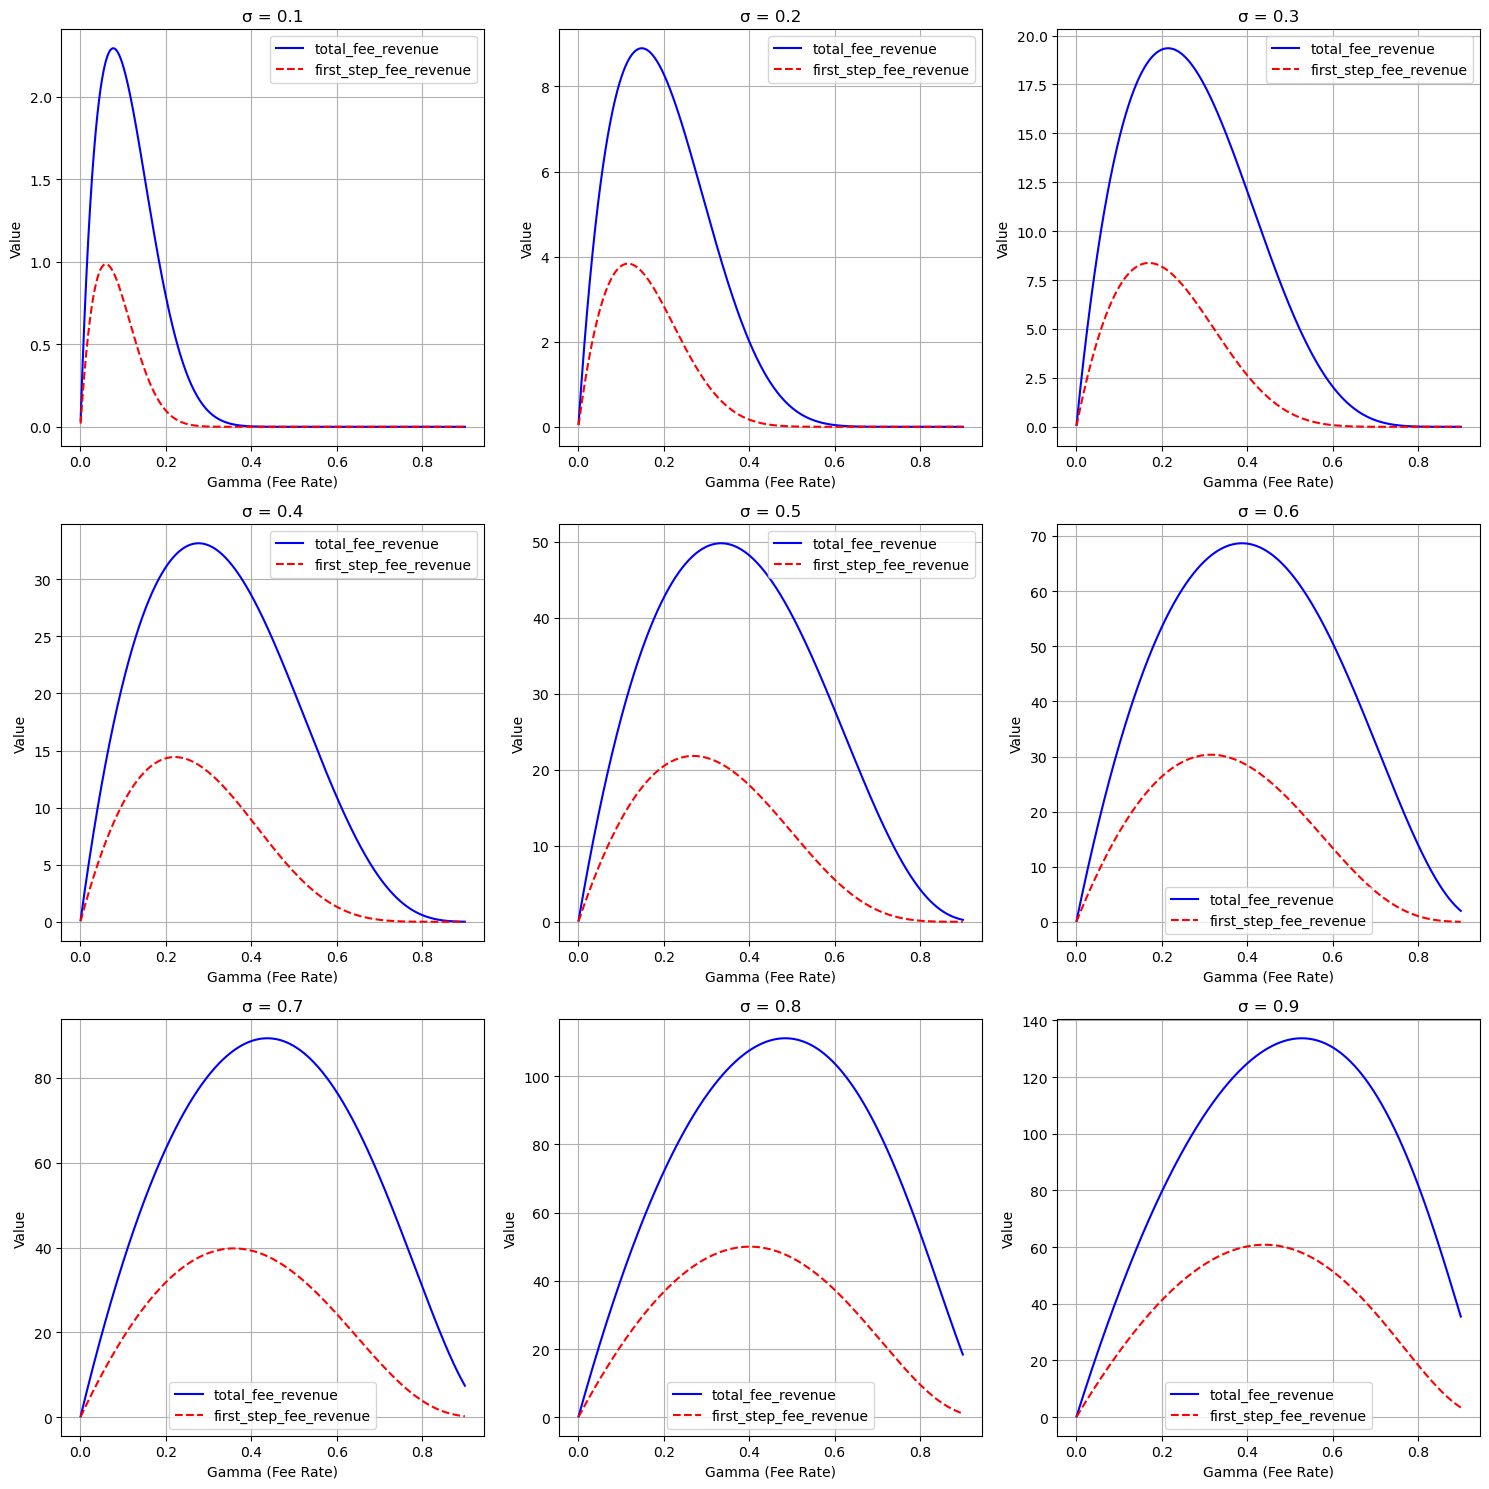

In [3]:
plot_metrics(df, ["total_fee_revenue", "first_step_fee_revenue"])

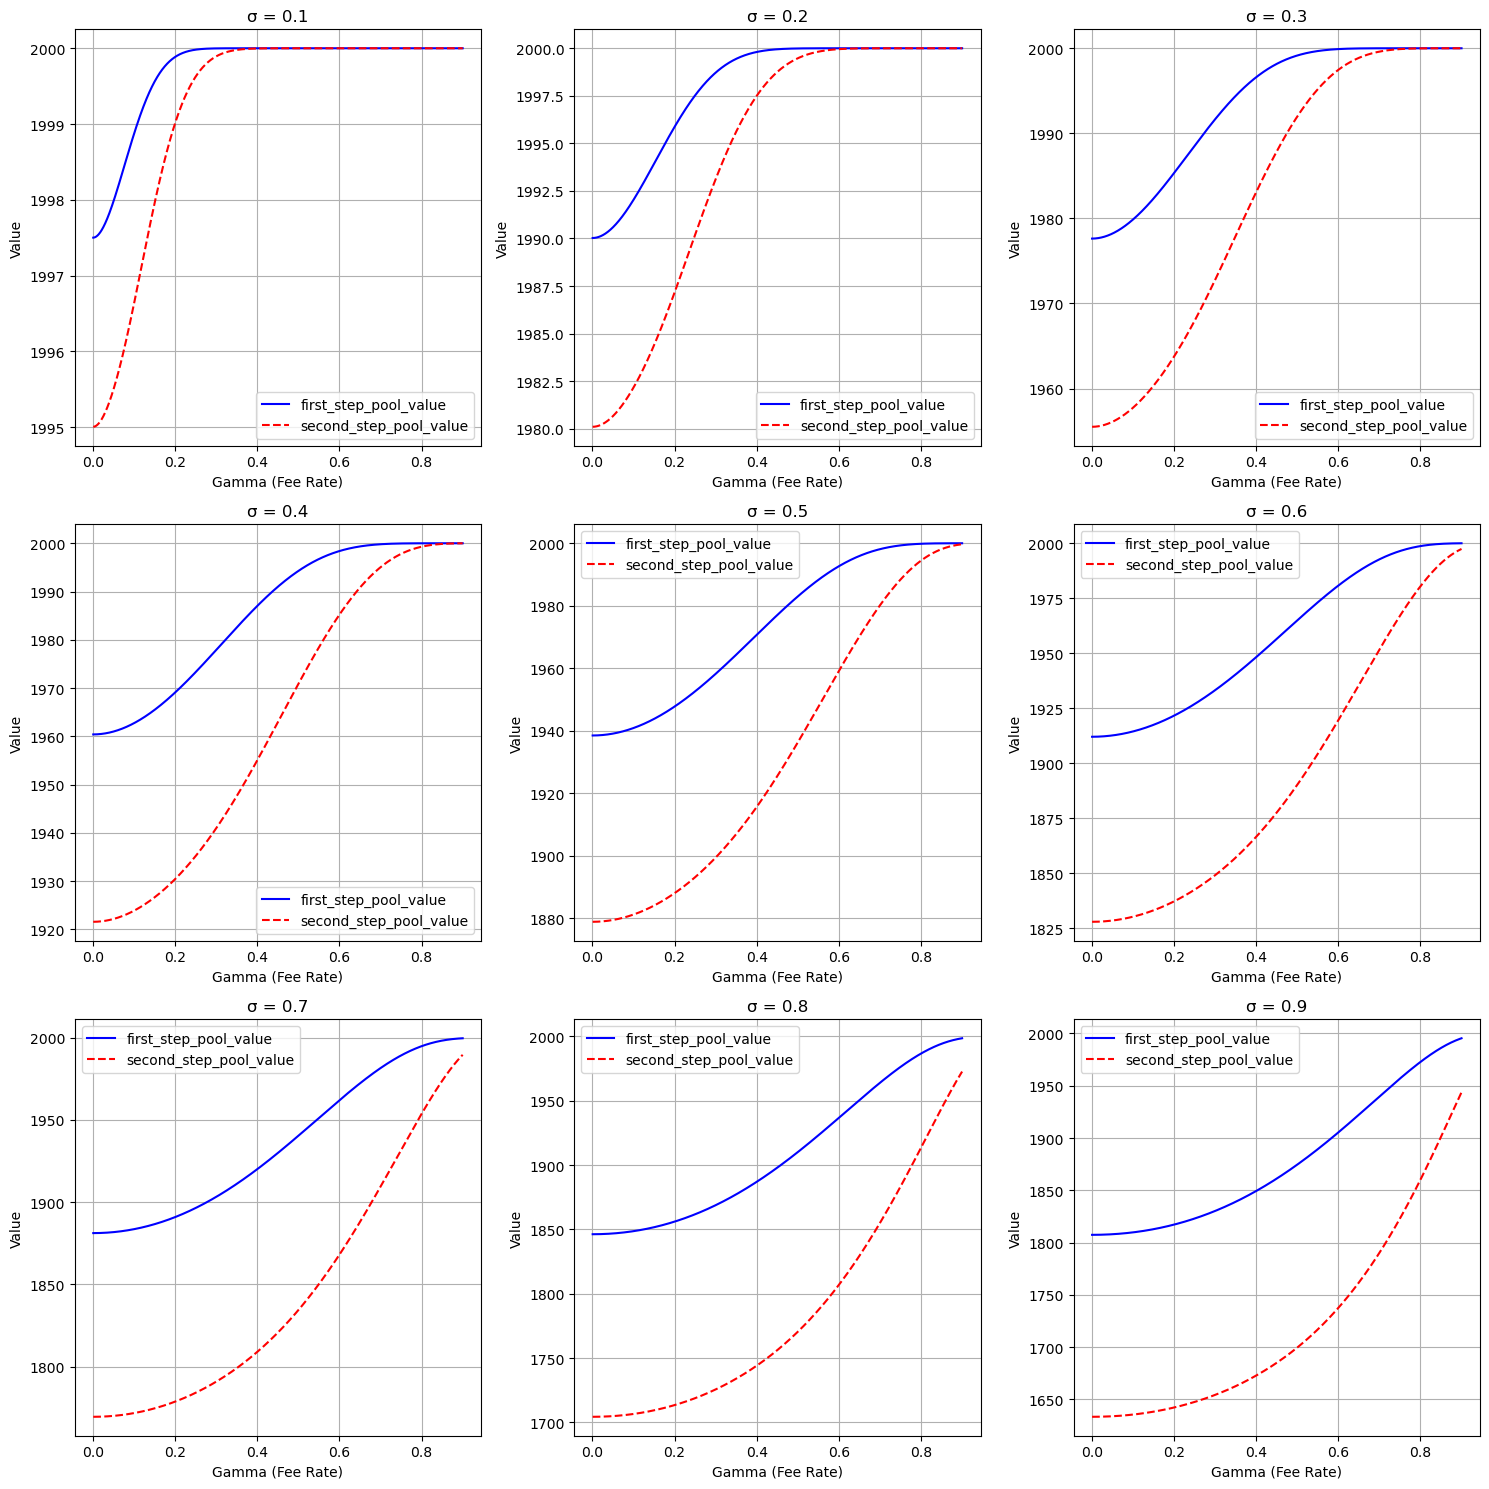

In [4]:
plot_metrics(df, ["first_step_pool_value", "second_step_pool_value"])

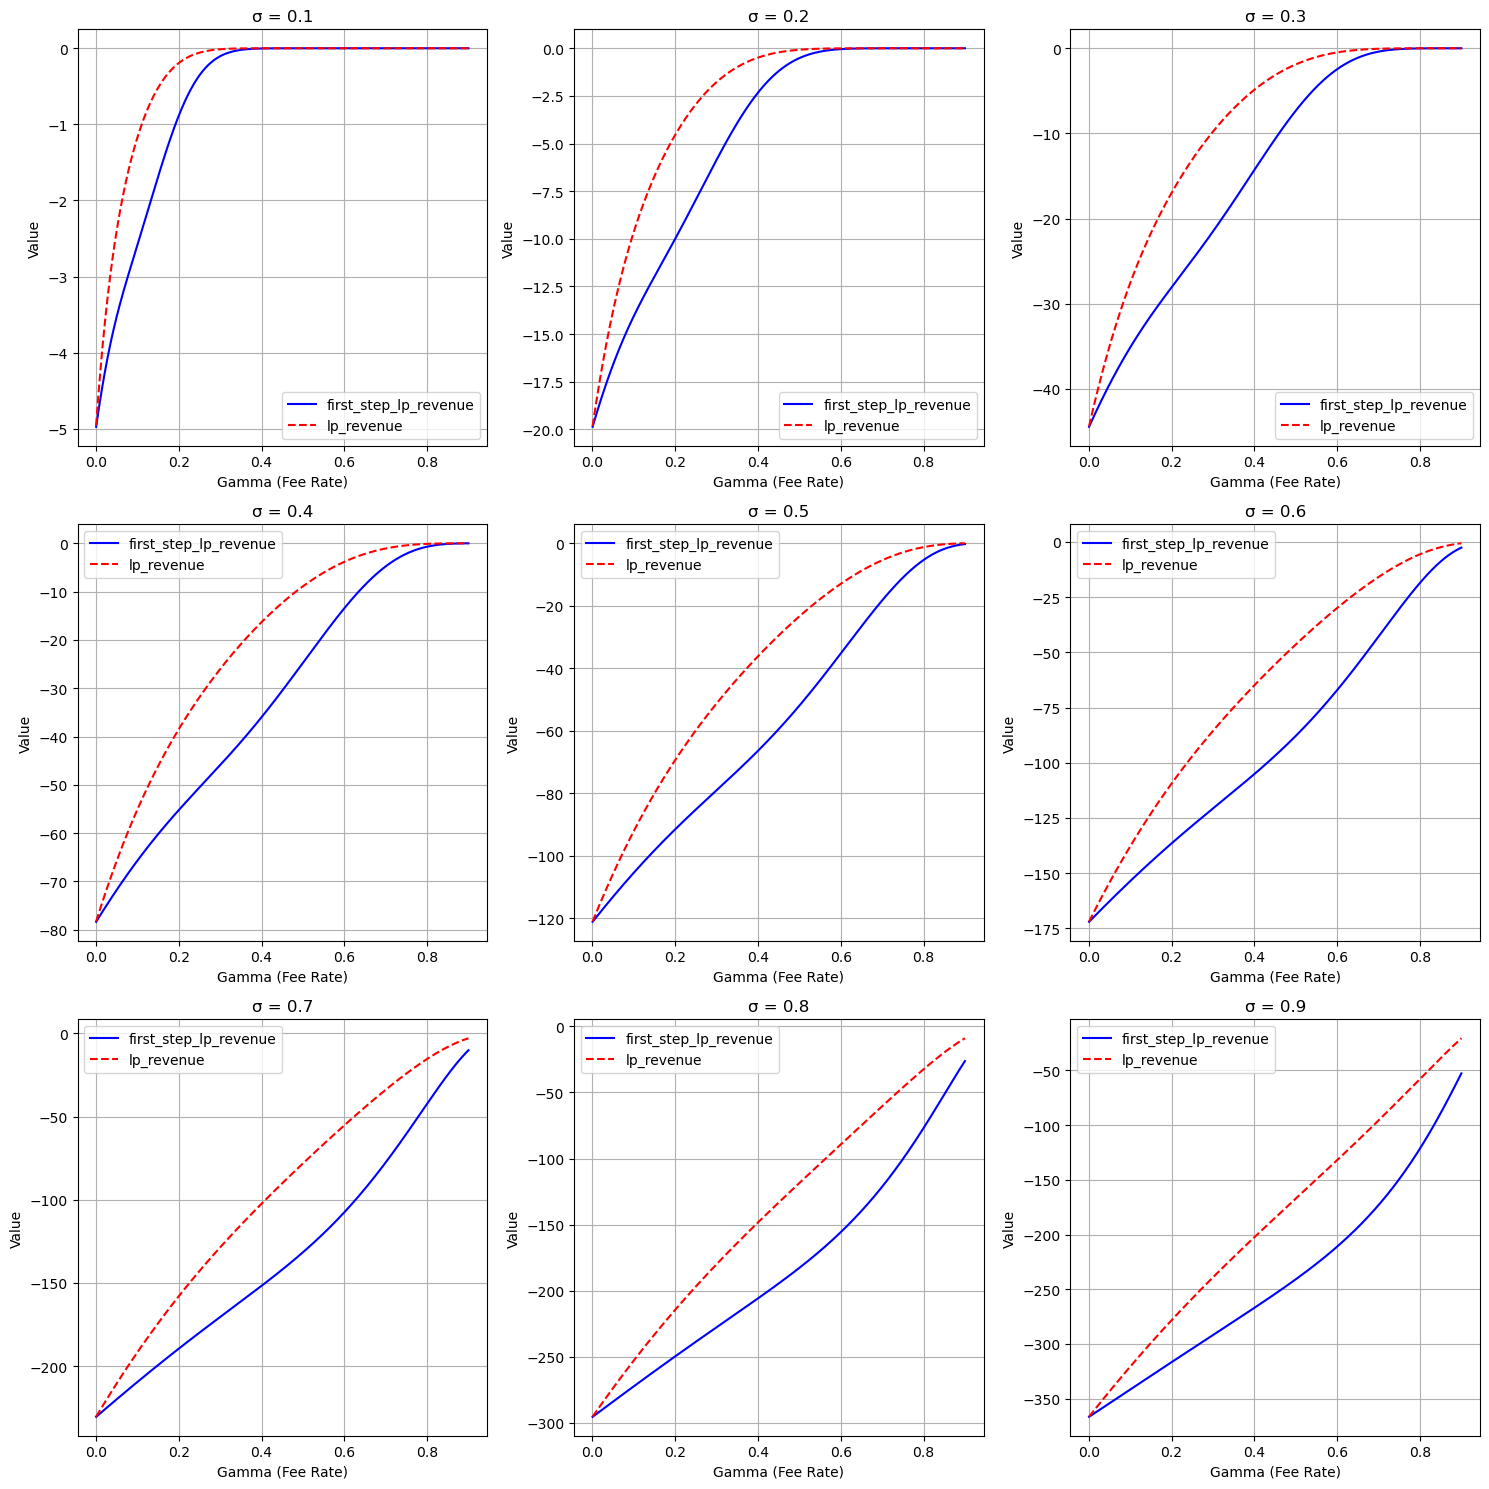

In [5]:
plot_metrics(df, ["first_step_lp_revenue", "lp_revenue"])